In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv("powerplant_data.csv")
df.head()
#AT => Temperature
#V => Vaccum
#AP => Pressure
#RH => Humidity
#PE => produce energy

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
X = df.drop("PE", axis=1)
y = df["PE"] 

In [4]:
#split out data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [6]:
from torch.utils.data import DataLoader, TensorDataset

train_tensor = TensorDataset(X_train_tensor, y_train_tensor)
test_tensor = TensorDataset(X_test_tensor, y_test_tensor)

In [7]:
train_loader = DataLoader(train_tensor, batch_size=32, shuffle=True)
test_loader = DataLoader(test_tensor, batch_size=32, shuffle=True)

# Deep Learning

In [8]:
#define our ANN model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()


        self.model = nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            #2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            #output lauyer
            nn.Linear(6, 1)
        )
    

    def forward(self, X):
        return self.model(X)

In [9]:
import torch.optim as optim

model = ANN()
criterion = nn.MSELoss()    
optimizer = optim.Adam(model.parameters())

In [10]:
#train ANN
best_validation_loss = float("inf")
train_losses =[]
validation_losses = []  #validation
epochs = 80

for epoch in range(epochs):
    model.train()
    running_loss = 0.0  #total training loss for 1 epoch

    for xb, yb in train_loader:
        #xb = feature of 1 batch
        #yb = labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb)  #forward propagation....predicted outputs for this batch
        loss = criterion(outputs, yb)  #compute/calculate loss
        loss.backward()  #back prop... compute gradients
        optimizer.step()  #params update
        
        running_loss += loss.item()  #loss is a tensor value => py float. convert tensor value to python float value

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)
    #training part finished

    #validation
    model.eval()
    running_validation_loss = 0.0

    with torch.no_grad(): #no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)  #this is our validation loss
            running_validation_loss += loss

    epoch_validation_loss = running_validation_loss / len(test_loader)  #length of test_load returns batch value
    validation_losses.append(epoch_validation_loss)


    print(f"epoch {epoch+1}/{epochs} ===> train loss = {epoch_train_loss} & validation loss = {epoch_validation_loss}")

    if epoch_validation_loss < best_validation_loss:
        best_validation_loss = epoch_validation_loss
        torch.save(model.state_dict(), "best_model.pt")  #extension can be .pt or .pth

epoch 1/80 ===> train loss = 206162.81959635418 & validation loss = 204206.953125
epoch 2/80 ===> train loss = 196873.76263020834 & validation loss = 184491.171875
epoch 3/80 ===> train loss = 162825.826953125 & validation loss = 136494.171875
epoch 4/80 ===> train loss = 106701.64459635416 & validation loss = 77777.421875
epoch 5/80 ===> train loss = 55521.76014811198 & validation loss = 38428.5625
epoch 6/80 ===> train loss = 29250.867810058593 & validation loss = 23304.994140625
epoch 7/80 ===> train loss = 19957.341682942708 & validation loss = 17597.75390625
epoch 8/80 ===> train loss = 15656.501557413738 & validation loss = 14016.4228515625
epoch 9/80 ===> train loss = 12409.939036051432 & validation loss = 10843.744140625
epoch 10/80 ===> train loss = 9413.231645711263 & validation loss = 7993.888671875
epoch 11/80 ===> train loss = 6800.673091634115 & validation loss = 5650.68896484375
epoch 12/80 ===> train loss = 4729.134692382812 & validation loss = 3863.601806640625
epoch 1

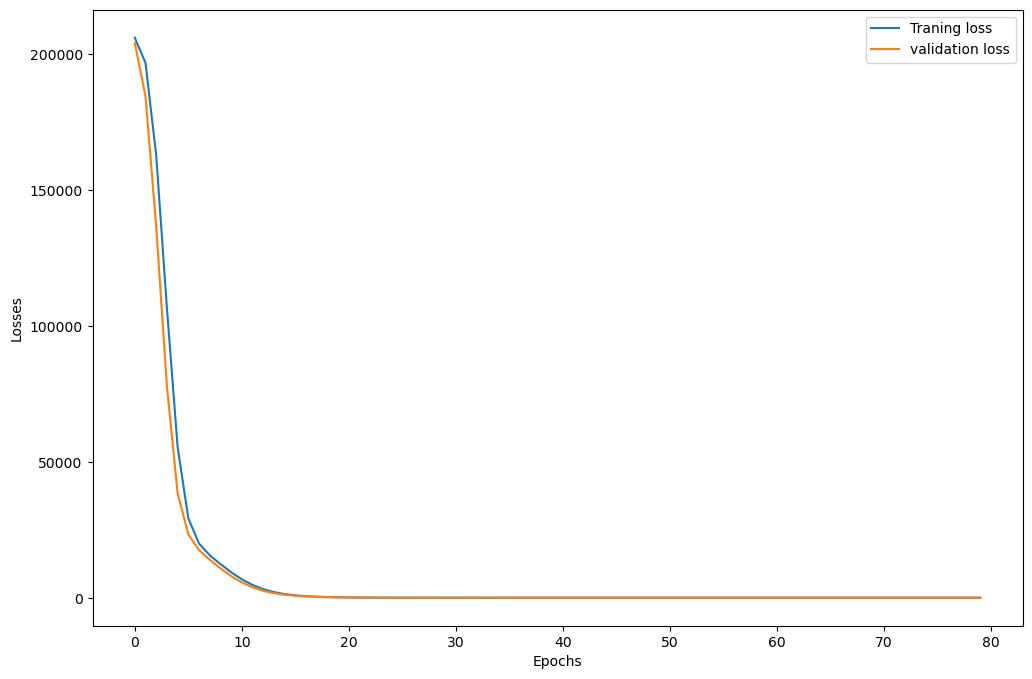

In [12]:
#visualization 
from matplotlib import pyplot as plt
loss_df = pd.DataFrame({
    "train_loss": train_losses,
    "validation_loss": validation_losses
})
plt.figure(figsize=(12,8))
plt.plot(loss_df["train_loss"], label = "Traning loss")
plt.plot(loss_df["validation_loss"], label = "validation loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [13]:
#loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [18]:
# Evaluation
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE", train_mse_loss.item())
print("Testning MSE", test_mse_loss.item())

Training MSE 21.177934646606445
Testning MSE 19.496816635131836


In [19]:
from sklearn.metrics import r2_score
print("R2 score: ", r2_score(y_test, test_preds))

R2 score:  0.9318636631140119


In [37]:

predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.764923,433.27
1,436.949615,438.16
2,461.510010,458.42
3,476.081024,480.82
4,436.096710,441.41
...,...,...
1909,451.178436,456.70
1910,431.897736,438.04
1911,467.802521,467.80
1912,431.336975,437.14


In [ ]:
# comparing performance with LinearRegression and SVR

# Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression
LR_model = LinearRegression()
LR_model.fit(X_train_scaled, y_train)

LinearRegression()

In [35]:

y_train_pred = LR_model.predict(X_train_scaled)
y_test_pred = LR_model.predict(X_test_scaled)

print("r2 score train:",r2_score(y_train, y_train_pred))
print("r2 score test:",r2_score(y_test, y_test_pred))



r2 score train: 0.9279951490925766
r2 score test: 0.9314747936670361


# SVR

In [44]:
from sklearn.svm import SVR

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
SVR_model_1 = SVR()
SVR_model_1.fit(X_train_scaled, y_train)

SVR()

In [46]:
y_test_pred = SVR_model_1.predict(X_test_scaled)
y_train_pred = SVR_model_1.predict(X_train_scaled)
print("r2 score train", r2_score(y_train, y_train_pred))
print("r2 score test",r2_score(y_test, y_test_pred))

r2 score train 0.9403984549767179
r2 score test 0.943254533099243


In [47]:
y_scaled = StandardScaler()
y_train_scaled = y_scaled.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = y_scaled.transform(y_test.values.reshape(-1, 1)).ravel()